# Figure 2

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  
from scipy.signal import savgol_filter
from tqdm import tqdm


100%|██████████| 12/12 [00:00<00:00, 25.85it/s]


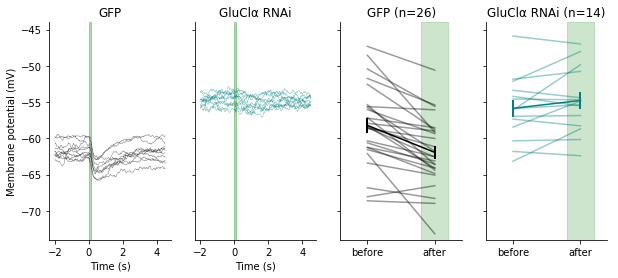

In [2]:
# Figure 2b, c:
# Load data:
data = pd.read_csv('fig2bc_vm.csv', index_col=None)
data.head()

# Average:
mean_data = data.groupby(['cell', 'genotype', 'dur', 'time']).\
            mean().reset_index()

# Calculate mean membrane potential
# in the 0.2 s preceding glutamate application ('before')
# and between 0.2 and 0.4 s 'after' glutamate application:
times = ["-0.2 <= time <= 0.0", "0.2 <= time <= 0.4"]
label = ['before', 'after']

df_readout = pd.DataFrame()
for g in mean_data.genotype.unique():
    for d in mean_data.query("genotype == @g").dur.unique():
        for c in tqdm(mean_data.query("genotype == @g and dur == @d").cell.unique()):
            m = mean_data.query("genotype ==@g and dur == @d and cell == @c")

            for idx, t in enumerate(times):
                df = pd.DataFrame()
                df['time'] = [label[idx]]
                df['genotype'] = [g]
                df['cell'] = [c]
                df['dur'] = [d]
                df['voltage'] = m.query(t).voltage.mean()

                df_readout = df_readout.append(df)

# Define exemplary cells/trials:
c1 = '20190206_T4-5'
c2 = '20190301_T4-1'
cs = [c1, c2]
ts = [63, 2]

titles = ['GFP', 'GluClα RNAi']
colours = ['k', 'teal']
pdsf = 20   # downsampling factor for plotting

# Define timeframe:
tmin = -2 
tmax = 4.5

# Create figure:
fig, ax = plt.subplots(1,4, figsize=(10, 4), sharey=True)
for idx, c in enumerate(cs):
    t = ts[idx]
    for s in np.arange(10):
        ax[idx].plot(data.query("cell == @c and trial == @t and sweep ==@s and @tmin <= time <= @tmax").time[::pdsf],
                   data.query("cell == @c and trial == @t and sweep ==@s and @tmin <= time <= @tmax").voltage[::pdsf],
                   color=colours[idx], alpha=0.5, linewidth=0.5)
        if c == '20190301_T4-1':
            ax[idx].plot(data.query("cell == @c and trial == 3 and sweep ==@s and @tmin <= time <= @tmax").time[::pdsf],
                   data.query("cell == @c and trial == 3 and sweep ==@s and @tmin <= time <= @tmax").voltage[::pdsf],
                   color=colours[idx], alpha=0.5, linewidth=0.5)
        ax[idx].set_title(titles[idx])
    ax[idx].axvspan(xmin=0.0, xmax=0.1, color='g', alpha=0.3)


d = df_readout.groupby(['time', 'cell', 'genotype']).mean().sort_values(by=['time'], ascending=False).reset_index()
d_mean = d.groupby(['time', 'genotype']).mean().reset_index()

width = 0.6
for idx, g in enumerate(data.genotype.unique()):
    ax[idx+2].axvspan(xmin=0.8, xmax=1.2, color='g', alpha=0.2)
    ax[idx+2].set_xlim(-0.4, 1.4)
    for c in d.query("genotype == @g").cell.unique():
        ax[idx+2].plot(d.query("genotype == @g and cell == @c").time,
                     d.query("genotype == @g and cell == @c").voltage, alpha=0.4, color=colours[idx])
        
    ax[idx+2].errorbar(0.3 - width/2, d_mean.query("genotype == @g and time == 'before'").voltage,
                       yerr=d.query("genotype == @g and time == 'before'").voltage.sem(), color=colours[idx], linewidth=2)
    ax[idx+2].errorbar(1.3 - width/2, d_mean.query("genotype == @g and time == 'after'").voltage,
                       yerr=d.query("genotype == @g and time == 'after'").voltage.sem(), color=colours[idx], linewidth=2)
    ax[idx+2].plot(d_mean.query("genotype == @g").time,
                     d_mean.query("genotype == @g").voltage, color=colours[idx])
    
ax[2].set_ylim(-74, -44)

for i in range(2):
    ax[i].set_xlabel('Time (s)')
ax[0].set_ylabel('Membrane potential (mV)')   
ax[0].set_ylim(-74, -44)
ax[2].set_title('GFP (n={})'.format(len(d.query("genotype == 'GFP'").cell.unique())))
ax[3].set_title('GluClα RNAi (n={})'.format(len(d.query("genotype == 'GluClα RNAi'").cell.unique())))
sns.despine()
#plt.savefig('fig2b-c.pdf');

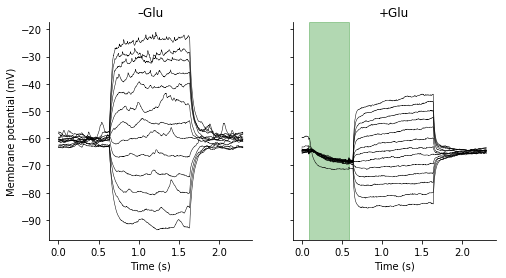

In [3]:
# Figure 2d (exemplary traces):
traces = pd.read_csv("fig2d_20190201_T4-2.csv", index_col=None)

trials = [0,1]
cond = ['–Glu', '+Glu']
fig, ax = plt.subplots(1,len(trials), figsize=(4*len(trials),4), sharey=True)

for idx, t in enumerate(trials): 
    for s in np.arange(13):
        ax[idx].plot(traces.query("trial == @t and sweep == @s").time,
                     traces.query("trial == @t and sweep == @s").voltage,
                     color = 'k', linewidth = 0.5)
        ax[idx].set_xlabel("Time (s)")
        ax[idx].set_title(cond[idx])
ax[0].set_ylabel("Membrane potential (mV)")
ax[-1].axvspan(0.090, 0.590, color='g', alpha=0.3)
sns.despine()
#plt.savefig('fig2d.pdf');


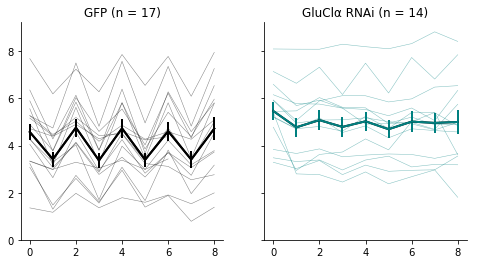

In [4]:
# Figure 2e:
# Load data:
data = pd.read_csv('fig2e_rin.csv', index_col=None)
data_mean = data.groupby(['genotype', 'trial']).mean().reset_index()
data_sem = data.groupby(['genotype', 'trial']).sem().reset_index()

# Plot:
colours = ['k', 'teal']

fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True)
for idx, g in enumerate(data.genotype.unique()):
    for c in data.query("genotype == @g").cell.unique():
        ax[idx].plot(data.query("cell == @c").trial,
             data.query("cell == @c").rin,
             color=colours[idx], alpha=0.5, linewidth=0.5)
    ax[idx].plot(data_mean.query("genotype == @g").trial,
                 data_mean.query("genotype == @g").rin, color='k', linewidth=2)
    ax[idx].errorbar(data_sem.query("genotype == @g").trial,
                     data_mean.query("genotype == @g").rin,
                     data_sem.query("genotype == @g").rin,
                     color=colours[idx], linewidth=2)
    ax[idx].set_title('{0} (n = {1})'.format(g, len(data.query("genotype == @g").cell.unique())))

sns.despine()
ax[0].set_ylim(0,);
#plt.savefig('fig2e.pdf')

/anaconda2/envs/PyClamp/lib/python3.7/site-packages/scipy/signal/_arraytools.py:45: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  b = a[a_slice]


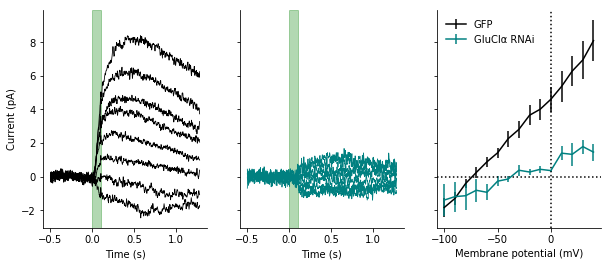

In [5]:
# Figure 2f:
# Load data:
data = pd.read_csv("fig2fedfig4b_currents.csv", index_col=None)
peak_data = pd.read_csv("fig2fedfig4b_iv.csv", index_col=None)

# Plot:
transmitters = ['Glu', 'GluClα RNAi']
labels = ['GFP', 'GluClα RNAi']
colours=['k', 'teal']

cd = data.groupby(['Transmitter', 'voltage', 'new_time']).mean().reset_index().query("Transmitter == @transmitters and voltage >= -100")
cdp = peak_data.query("Transmitter == @transmitters and voltage >= -100")
cdp_mean = cdp.groupby(['Transmitter', 'voltage']).mean().reset_index()
cdp_sem = cdp.groupby(['Transmitter', 'voltage']).sem().reset_index()
pdsf = 5 # downsample for plotting

fig, ax = plt.subplots(1, len(cd.Transmitter.unique())+1, figsize=(10, 4), sharey=True)
sns.despine()
for idx, t in enumerate(transmitters):
    for v in cd.voltage.unique()[::2]:
        ax[idx].plot(cd.query("Transmitter == @t and voltage == @v").new_time[::pdsf], 
                     savgol_filter(cd.query("Transmitter == @t and voltage == @v").current, 35, 2)[::pdsf], c=colours[idx], alpha=1.0, linewidth=0.8)
    ax[idx].set_xlabel('Time (s)')
    ax[idx].axvspan(0, 0.1, color='g', alpha=0.3)
    ax[-1].errorbar(cdp_mean.query("Transmitter == @t").voltage, cdp_mean.query("Transmitter == @t").current,
            yerr=cdp_sem.query("Transmitter == @t").current, c=colours[idx], label=labels[idx])
    
ax[-1].axhline(y = 0, color='k',linestyle='dotted')
ax[-1].axvline(x = 0, color='k',linestyle='dotted')
ax[0].set_ylabel('Current (pA)')
ax[-1].set_xlabel('Membrane potential (mV)')
plt.legend(frameon=False);
#plt.savefig('fig2f.pdf');

GFP (n = 192)
GluClα RNAi (n = 103)


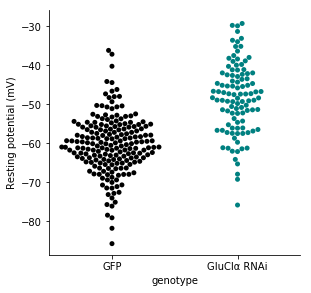

In [6]:
# Figure 2g:
# Load resting membrane potential data:
data = pd.read_csv('fig2g_rmp.csv', index_col=None)

# Plot:
fig, ax = plt.subplots(1,1, figsize=(4.5,4.5))
sns.swarmplot(data=data.query("genotype == ['GFP', 'GluClα RNAi']"), x="genotype", y="voltage", ax=ax, palette=['k', 'teal'])
ax.set_ylabel('Resting potential (mV)')
sns.despine()
print('GFP (n = {})'.format(len(data.query("genotype =='GFP'").cell.unique())))
print('GluClα RNAi (n = {})'.format(len(data.query("genotype =='GluClα RNAi'").cell.unique())))
#plt.savefig('fig2g.pdf')

GFP (n = 209)
GluClα RNAi (n = 105)


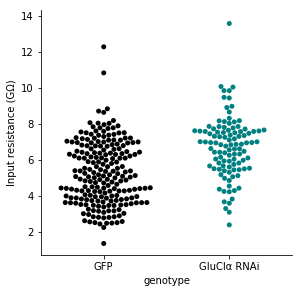

In [7]:
# Figure 2h:
# Load input resistance data:
data = pd.read_csv('fig2h_rin.csv', index_col=None)

# Plot:
fig, ax = plt.subplots(1,1, figsize=(4.5,4.5))
sns.swarmplot(data=data.query("genotype == ['GFP', 'GluClα RNAi']"), x="genotype", y="rin", ax=ax, palette=['k', 'teal'])
ax.set_ylabel('Input resistance (GΩ)')
sns.despine()
print('GFP (n = {})'.format(len(data.query("genotype =='GFP'").cell.unique())))
print('GluClα RNAi (n = {})'.format(len(data.query("genotype =='GluClα RNAi'").cell.unique())))
#plt.savefig('fig2h.pdf')